# Word2Vec Hyperparameter Optimization with Optuna                               

Bayesian hyperparameter search (TPE) for Skip-Gram with Negative Sampling.

- **Metric:** Spearman ρ on WordSim-353 word similarity benchmark
- **Budget:** Full Text8 dataset (~17M tokens), 10 trials with MedianPruner
- **Search space:** 8 hyperparameters (embedding_dim, window, neg_samples, lr_start, lr_min, min_count, epochs, subsample_t)

In [41]:
import csv
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import optuna
from scipy.stats import spearmanr
import joblib
import matplotlib.pyplot as plt
import pandas as pd

from word2vec.model import SkipGramNS
from word2vec.preprocessing import (
    apply_subsampling,
    build_negative_sampling_table,
    build_vocab,
    generate_training_pairs,
    subsample_probs,
    tokenize,
)
from word2vec.training import train, train_epoch

optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

## 1. Load Text8 and WordSim-353

In [42]:
# --- Text8 ---
text8_file = DATA_DIR / "text8"
if not text8_file.exists():
    zip_path = DATA_DIR / "text8.zip"
    if not zip_path.exists():
        print("Downloading text8...")
        urlretrieve("http://mattmahoney.net/dc/text8.zip", str(zip_path))
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_DIR)

text = text8_file.read_text()
tokens = tokenize(text)
print(f"Text8 tokens: {len(tokens):,}")

# --- WordSim-353 ---
wordsim_file = DATA_DIR / "wordsim353.csv"
if not wordsim_file.exists():
    print("Downloading WordSim-353...")
    ws_zip = DATA_DIR / "wordsim353.zip"
    urlretrieve(
        "https://gabrilovich.com/resources/data/wordsim353/wordsim353.zip",
        str(ws_zip),
    )
    with zipfile.ZipFile(ws_zip) as zf:
        with zf.open("combined.csv") as src, open(wordsim_file, "wb") as dst:
            dst.write(src.read())

wordsim_pairs = []
with open(wordsim_file) as f:
    reader = csv.DictReader(f)
    for row in reader:
        w1 = row["Word 1"].lower()
        w2 = row["Word 2"].lower()
        score = float(row["Human (mean)"])
        wordsim_pairs.append((w1, w2, score))

print(f"WordSim-353 pairs: {len(wordsim_pairs)}")

Text8 tokens: 17,005,207
WordSim-353 pairs: 353


## 2. Evaluation Function

Compute Spearman correlation between model cosine similarities and human judgments on WordSim-353.

In [3]:
def evaluate_wordsim(model: SkipGramNS, vocab_word2id: dict[str, int]) -> float:
    """Compute Spearman rho on WordSim-353 pairs present in vocabulary."""
    norms = np.linalg.norm(model.w_in, axis=1, keepdims=True) + 1e-10
    normalized = model.w_in / norms

    human_scores = []
    model_scores = []

    for w1, w2, score in wordsim_pairs:
        if w1 in vocab_word2id and w2 in vocab_word2id:
            v1 = normalized[vocab_word2id[w1]]
            v2 = normalized[vocab_word2id[w2]]
            model_scores.append(float(v1 @ v2))
            human_scores.append(score)

    if len(human_scores) < 10:
        return 0.0

    rho, _ = spearmanr(human_scores, model_scores)
    return float(rho)

## 3. Optuna Objective

Each trial: preprocess with sampled hyperparameters -> train -> evaluate on WordSim-353.

Uses `MedianPruner` to early-stop unpromising trials after each epoch.

In [4]:
def objective(trial: optuna.Trial) -> float:
    # --- Sample hyperparameters ---
    embedding_dim = trial.suggest_categorical("embedding_dim", [50, 100, 200, 300])
    window = trial.suggest_int("window", 2, 10)
    neg_samples = trial.suggest_int("neg_samples", 2, 15)
    lr_start = trial.suggest_float("lr_start", 0.005, 0.1, log=True)
    lr_min = trial.suggest_float("lr_min", 1e-5, 1e-3, log=True)
    min_count = trial.suggest_int("min_count", 3, 20)
    epochs = trial.suggest_int("epochs", 3, 10)
    subsample_t = trial.suggest_float("subsample_t", 1e-6, 1e-4, log=True)

    # --- Preprocessing (depends on min_count, subsample_t, window) ---
    vocab = build_vocab(tokens, min_count=min_count)
    if len(vocab.words) < 100:
        return 0.0

    rng = np.random.default_rng(42)
    token_ids = np.array([vocab.word2id[w] for w in tokens if w in vocab.word2id])
    discard_probs = subsample_probs(vocab.freqs, t=subsample_t)
    token_ids = apply_subsampling(token_ids, discard_probs, rng)
    pairs = generate_training_pairs(token_ids, window_size=window)
    neg_table = build_negative_sampling_table(vocab.freqs)

    # --- Train with per-epoch pruning ---
    model = SkipGramNS(vocab_size=len(vocab.words), embedding_dim=embedding_dim, seed=42)
    train_rng = np.random.default_rng(42)

    for epoch in range(epochs):
        lr = lr_start - (lr_start - lr_min) * (epoch / max(epochs - 1, 1))
        train_epoch(model, pairs, neg_table, lr, neg_samples, train_rng, batch_size=256)

        # Evaluate after each epoch for pruning
        rho = evaluate_wordsim(model, vocab.word2id)
        trial.report(rho, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return evaluate_wordsim(model, vocab.word2id)

## 4. Run Optimization

In [7]:
N_TRIALS = 10

study = optuna.create_study(
    direction="maximize",
    study_name="word2vec-hpo",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [25]:
joblib.dump(study, "../data/study_hpo.pkl")

['../data/study_hpo.pkl']

## 5. Results

In [8]:
print(f"Best Spearman rho: {study.best_value:.4f}")
print(f"Best trial: #{study.best_trial.number}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Spearman rho: 0.7064
Best trial: #6

Best hyperparameters:
  embedding_dim: 300
  window: 6
  neg_samples: 13
  lr_start: 0.01643053260688297
  lr_min: 0.00012823590584347237
  min_count: 11
  epochs: 10
  subsample_t: 2.910085582820259e-05


## 6. Visualization

In [33]:
from optuna.visualization.matplotlib import (
    plot_param_importances,
    plot_intermediate_values
)

/var/folders/5d/lr6pp1tx31n_yxmkwn7_rtp80000gn/T/ipykernel_87067/853070263.py:1: ExperimentalWarning: optuna.visualization.matplotlib._intermediate_values.plot_intermediate_values is experimental (supported from v2.2.0). The interface can change in the future.
  plot_intermediate_values(study);


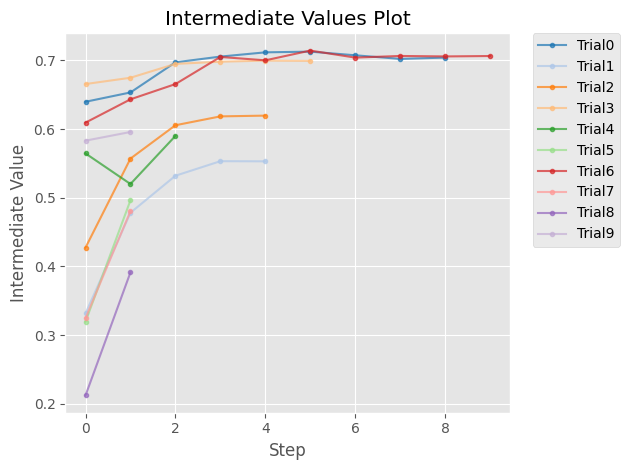

In [35]:
plot_intermediate_values(study);

Pruning in action — trials starting below ρ ≈ 0.5 after epoch 0 never recover and are correctly killed early. Best trials (0, 6) plateau after ~5 epochs,
suggesting longer training yields diminishing returns. Only 3 out of 10 trials completed fully.

/var/folders/5d/lr6pp1tx31n_yxmkwn7_rtp80000gn/T/ipykernel_87067/2122237422.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study);


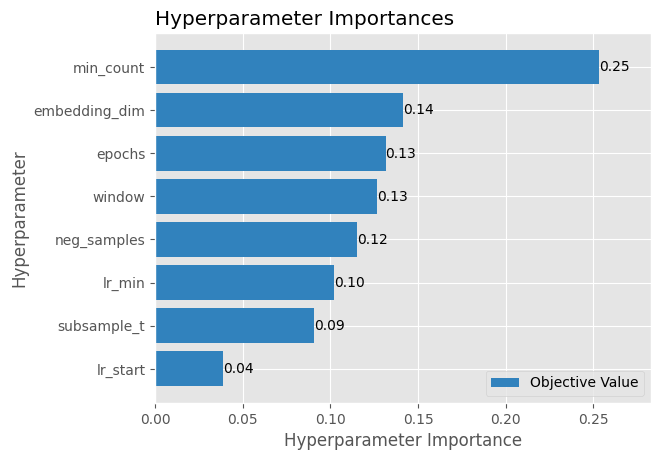

In [11]:
plot_param_importances(study);

## 7. Retrain Best Model

In [14]:
best = study.best_params

# Preprocess with best params
best_vocab = build_vocab(tokens, min_count=best["min_count"])
rng = np.random.default_rng(42)
token_ids = np.array([best_vocab.word2id[w] for w in tokens if w in best_vocab.word2id])
discard_probs = subsample_probs(best_vocab.freqs, t=best["subsample_t"])
token_ids = apply_subsampling(token_ids, discard_probs, rng)
pairs = generate_training_pairs(token_ids, window_size=best["window"])
neg_table = build_negative_sampling_table(best_vocab.freqs)

# Train
best_model = SkipGramNS(
    vocab_size=len(best_vocab.words),
    embedding_dim=best["embedding_dim"],
    seed=42,
)
loss_history = train(
    best_model,
    pairs,
    neg_table,
    epochs=best["epochs"],
    lr_start=best["lr_start"],
    lr_min=best["lr_min"],
    neg_samples=best["neg_samples"],
)

final_rho = evaluate_wordsim(best_model, best_vocab.word2id)
print(f"\nFinal WordSim-353 Spearman rho: {final_rho:.4f}")

Epoch 1/10 | LR: 0.016431 | Avg Loss: 3.3713


Epoch 2/10 | LR: 0.014619 | Avg Loss: 3.0761


Epoch 3/10 | LR: 0.012808 | Avg Loss: 2.9969


Epoch 4/10 | LR: 0.010996 | Avg Loss: 2.9448


Epoch 5/10 | LR: 0.009185 | Avg Loss: 2.9068


Epoch 6/10 | LR: 0.007374 | Avg Loss: 2.8768


Epoch 7/10 | LR: 0.005562 | Avg Loss: 2.8520


Epoch 8/10 | LR: 0.003751 | Avg Loss: 2.8306


Epoch 9/10 | LR: 0.001940 | Avg Loss: 2.8117


Epoch 10/10 | LR: 0.000128 | Avg Loss: 2.7953

Final WordSim-353 Spearman rho: 0.7005


In [39]:
best_model.save("../data/best_model.npz")
joblib.dump(best_vocab, "../data/best_vocab.pkl")

['../data/best_vocab.pkl']

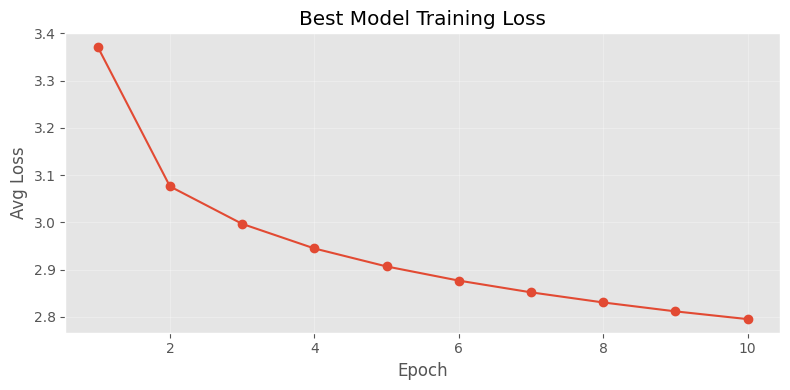

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.title("Best Model Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 8. Qualitative Evaluation

### Nearest Neighbors

In [15]:
query_words = ["king", "queen", "computer", "water", "one", "good", "city", "war"]

norms = np.linalg.norm(best_model.w_in, axis=1, keepdims=True) + 1e-10
normalized = best_model.w_in / norms

for word in query_words:
    if word not in best_vocab.word2id:
        continue
    wid = best_vocab.word2id[word]
    sims = normalized @ normalized[wid]
    sims[wid] = -1
    top_ids = np.argsort(sims)[::-1][:5]
    neighbors = ", ".join(f"{best_vocab.id2word[i]} ({sims[i]:.3f})" for i in top_ids)
    print(f"{word:>10s} -> {neighbors}")

      king -> posthumus (0.559), kings (0.542), dunkeld (0.534), crowned (0.533), ladislaus (0.524)
     queen -> elizabeth (0.565), regnant (0.533), monarch (0.505), dagmar (0.504), wolsey (0.498)
  computer -> computers (0.706), hardware (0.630), computing (0.599), software (0.596), windowing (0.575)
     water -> desalination (0.585), evaporates (0.584), potable (0.557), wastewater (0.554), evaporating (0.549)
       one -> seven (0.773), nine (0.748), eight (0.737), six (0.733), two (0.723)
      good -> bad (0.496), natured (0.464), py (0.457), naughty (0.449), dervish (0.438)
      city -> town (0.583), suburbs (0.546), dekalb (0.539), downtown (0.532), cities (0.532)
       war -> allied (0.571), bloodiest (0.560), guerillas (0.552), troops (0.543), army (0.536)


### Word Analogies

In [28]:
def analogy(w_pos, w_neg, vocab, normalized, top_n=5):
    """Solve: w_pos[0] - w_neg + w_pos[1] = ?"""
    vec = normalized[vocab.word2id[w_pos[0]]] - normalized[vocab.word2id[w_neg]] + normalized[vocab.word2id[w_pos[1]]]
    vec = vec / (np.linalg.norm(vec) + 1e-10)
    sims = normalized @ vec
    # Exclude query words
    for w in w_pos + [w_neg]:
        sims[vocab.word2id[w]] = -1
    top_ids = np.argsort(sims)[::-1][:top_n]
    return [(best_vocab.id2word[i], f"{sims[i]:.3f}") for i in top_ids]

test_analogies = [
    (["king", "woman"], "man"),      # king - man + woman = queen?
    (["paris", "germany"], "france"), # paris - france + germany = berlin?
    (["bigger", "cold"], "big"),      # bigger - big + cold = colder?
    (["king", "women"], "kings"),     # king - kings + women = woman? (singular/plural)
]

for w_pos, w_neg in test_analogies:
    results = analogy(w_pos, w_neg, best_vocab, normalized)
    expr = f"{w_pos[0]} - {w_neg} + {w_pos[1]}"
    top_words = ", ".join(f"{w} ({s})" for w, s in results)
    print(f"{expr:>30s} = {top_words}")

            king - man + woman = betrothed (0.439), throne (0.434), queen (0.426), anjou (0.416), childless (0.394)
      paris - france + germany = berlin (0.522), stadtbahn (0.472), unter (0.468), dresden (0.467), neberg (0.459)
           bigger - big + cold = containment (0.378), colder (0.349), warmer (0.340), cooler (0.340), temperatures (0.338)
          king - kings + women = cady (0.442), woman (0.432), men (0.421), misogynist (0.418), louisa (0.413)


## 9. Summary

**Best result:** Spearman ρ = 0.706 on WordSim-353 (trial #6).

**Optimal hyperparameters:** `embedding_dim=300`, `window=6`, `neg_samples=13`, `min_count=11`, `epochs=10`, `lr_start≈0.016`, `subsample_t≈2.9e-5`.

**Key findings:**
- `min_count` is the most impactful hyperparameter — vocabulary filtering directly affects both training quality and benchmark coverage
- 5–6 epochs are sufficient; longer training shows diminishing returns on ρ
- Starting learning rate has minimal impact in the 0.005–0.1 range
- Higher embedding dimension (300) and more negative samples (13) favor quality on this dataset

**Limitations:**
- 10 trials with 8 parameters is a sparse search — TPE needs ~20+ trials to effectively model the hyperparameter distribution
- Text8 (17M tokens) caps achievable quality; larger corpora would improve both ρ and analogy accuracy
- Evaluation on a single benchmark (WordSim-353) may not capture all aspects of embedding quality